In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests, ccf
import numpy as np
import plotly.express as px
from datetime import datetime
import geopandas as gpd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
from utils import *
import plotly.io as pio
pio.renderers.default = 'vscode'  # or 'notebook'

In [12]:
import geopandas

#Load the NWS zones shapefile
zones = geopandas.read_file('../Data/z_05mr24.zip')

#Load the counties zones shapefile
counties = geopandas.read_file('../Data/cb_2023_us_county_500k.zip')

In [15]:
counties.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3235 entries, 0 to 3234
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   STATEFP     3235 non-null   object  
 1   COUNTYFP    3235 non-null   object  
 2   COUNTYNS    3235 non-null   object  
 3   GEOIDFQ     3235 non-null   object  
 4   GEOID       3235 non-null   object  
 5   NAME        3235 non-null   object  
 6   NAMELSAD    3235 non-null   object  
 7   STUSPS      3235 non-null   object  
 8   STATE_NAME  3235 non-null   object  
 9   LSAD        3235 non-null   object  
 10  ALAND       3235 non-null   int64   
 11  AWATER      3235 non-null   int64   
 12  geometry    3235 non-null   geometry
dtypes: geometry(1), int64(2), object(10)
memory usage: 328.7+ KB


In [16]:
#Restrict zones to the continental US
zones = zones[(zones['STATE'] != 'HI') & (zones['STATE'] != 'AK') & (zones['STATE'] != 'PR') & (zones['STATE'] != 'VI') & (zones['STATE'] != 'GU') & (zones['STATE'] != 'MP') & (zones['STATE'] != 'AS') & (zones['STATE'] != 'FM') & (zones['STATE'] != 'MH') & (zones['STATE'] != 'PW')]

#Restrict counties to the continental US
counties = counties[(counties['STATEFP'] != '15') & (counties['STATEFP'] != '02') & (counties['STATEFP'] != '72') & (counties['STATEFP'] != '69') & (counties['STATEFP'] != '60') & (counties['STATEFP'] != '64') & (counties['STATEFP'] != '66') & (counties['STATEFP'] != '78')]

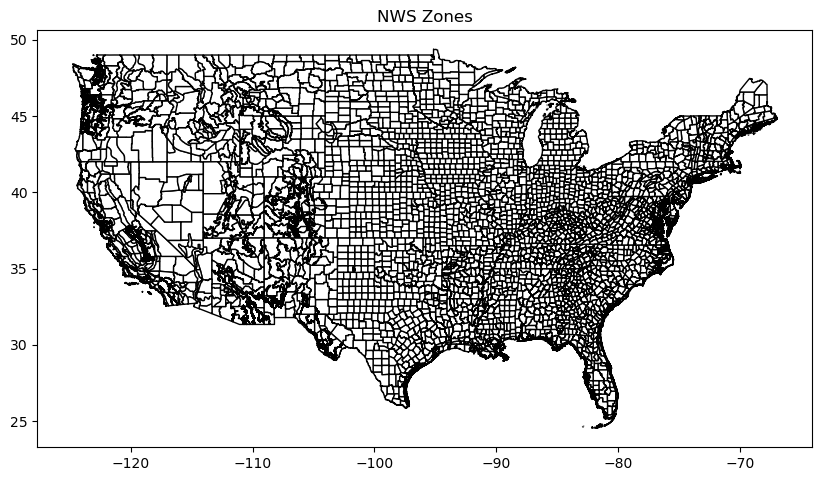

In [ ]:
#Make a plot of zones
fig, ax = plt.subplots(figsize=(10, 10))
zones.plot(ax=ax, color='white', edgecolor='black')
ax.set_title('NWS Zones')
plt.show()

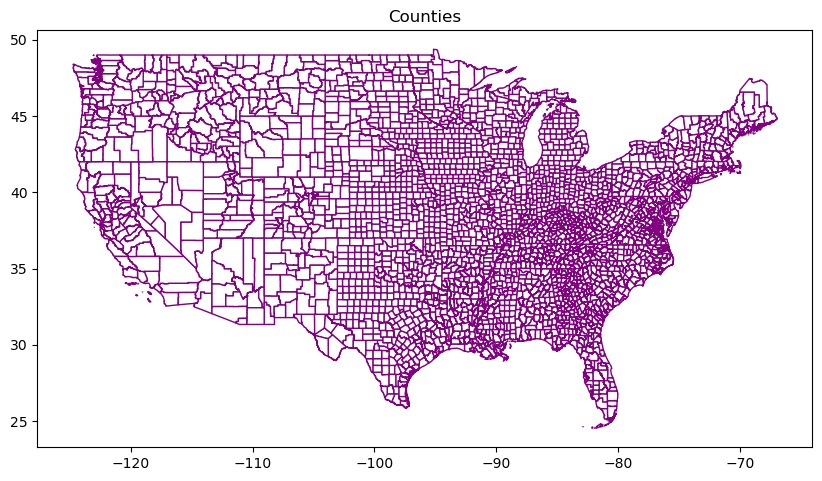

In [20]:
#Make a plot of counties in purple
fig, ax = plt.subplots(figsize=(10, 10))
counties.plot(ax=ax, color='white', edgecolor='purple')
ax.set_title('Counties')
plt.show()

In [10]:
#Make a dataframe that includes the STATE, ZONE, CWA, NAME, TIME_ZONE, LON, LAT, and SHORTNAME
zones_df = zones[['STATE', 'ZONE', 'CWA', 'NAME', 'TIME_ZONE', 'LON','LAT','geometry']]


In [21]:
#For each ZONE in zones_df, identify the COUNTY it lies in
zones_df['COUNTY'] = zones_df.apply(lambda x: counties[counties.geometry.intersects(x.geometry)].NAME.values[0], axis=1)

In [23]:
#Add the FIPS code for the COUNTY
zones_df['COUNTY_FIPS'] = zones_df.apply(lambda x: counties[counties.geometry.intersects(x.geometry)].GEOID.values[0], axis=1)

In [24]:
zones_df

,STATE,ZONE,CWA,NAME,TIME_ZONE,LON,LAT,geometry,COUNTY,COUNTY_FIPS
0,AL,019,BMX,Calhoun,C,-85.8261,33.7714,"POLYGON ((-85.5301 33.94181, -85.532 33.89771,...",Etowah,01055
1,AL,057,MOB,Butler,C,-86.6803,31.7524,"POLYGON ((-86.448 31.96431, -86.44769 31.95271...",Monroe,01099
2,AL,046,BMX,Bullock,C,-85.7161,32.1005,"POLYGON ((-85.43349 32.23421, -85.4312 32.1987...",Barbour,01005
3,AL,017,BMX,Blount,C,-86.5674,33.9809,"POLYGON ((-86.45229 34.25951, -86.4442 34.2577...",Etowah,01055
4,AL,034,BMX,Bibb,C,-87.1264,32.9986,"POLYGON ((-87.02679 33.24601, -87.02599 33.231...",Shelby,01117
...,...,...,...,...,...,...,...,...,...,...
4058,WA,202,PQR,Willapa and Wahkiakum Lowlands,P,-123.5766,46.4823,"MULTIPOLYGON (((-123.3353 46.16043, -123.33172...",Pacific,53049
4059,WA,211,PQR,South Washington Cascades,P,-122.0135,46.0559,"POLYGON ((-121.75819 46.38841, -121.7407 46.38...",Lewis,53041
4060,OR,113,PQR,Outer Southeast Portland Metro,P,-122.3697,45.3705,"POLYGON ((-122.32391 45.49482, -122.31913 45.4...",Multnomah,41051
4061,OR,106,PQR,North Oregon Coast Range,P,-123.4735,45.6454,"MULTIPOLYGON (((-123.43033 46.14816, -123.4290...",Clatsop,41007
